# Import

In [1]:
import tomllib
from typing import Literal
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import RemoveMessage, HumanMessage, AIMessage, SystemMessage

c:\Users\ssrim\anaconda3\envs\lc-academy-env\Lib\site-packages\langchain_core\utils\pydantic.py:41: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1


In [2]:
t = HumanMessage("Heelo")

In [3]:
# Loading secrets to get API key

with open("../secrets.toml", "rb") as f:
    secrets = tomllib.load(f)

In [4]:
llm = ChatOpenAI(model="gpt-4o", api_key=secrets["api_keys"]["openai"])
llm.invoke("Hello world")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 9, 'total_tokens': 18, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_f38a9d6fcb', 'id': 'chatcmpl-DvIBIzNv6a0W5GTspMMsTMjtu6EYg', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f0814-0188-7f91-8ffe-d8472a20e931-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 9, 'total_tokens': 18, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [5]:
# Crerating a state that has a summary of the conversation
class State(MessagesState):
    summary: str

In [6]:
def summarize_conversation(state: State) -> State:
    
    summary = state.get("summary", "")
    messages_to_summarize = state["messages"][:5]

    summarize = ""
    for m in messages_to_summarize:
        summarize += f"{m.type}: "
        summarize += m.content

    if not messages_to_summarize:
        return {"summary": summary, "messages": []}

    prompt = (
        f"The conversation summary so far is: {summary}. "
        "Create a new summary that incorporates the previous summary and the messages below."
        "Highlight what was asked by the user and what was responded by the AI."
        "Do not attempt to answer the queries asked. Only summarize what was asked and answered."
    )
    new_summary = llm.invoke([SystemMessage(content=prompt), HumanMessage(summarize)]).content
    remove_messages = [RemoveMessage(id=m.id) for m in messages_to_summarize]
    return {"summary": new_summary, "messages": remove_messages}

**NOTE:**

Big important note. As per the example given by LangChain, all of the messages that are to be summarized, can be given as is without any preprocessing. Example:
```
new_summary = llm.invoke([SystemMessage(content=prompt)] + [messages_to_summarize]).content
```

However, what is happening when the messages are directly provided as Message objects is that instead of attempting to summarize the full list of messages, the LLM is trying to answer the last question asked by the user. Thus, all of the previous messages are preprocessed by wrapping them into a sigle text/HumanMessage.

This may depend on the chat model used. However, this should be checked.

In [7]:
def call_llm(state: State) -> State:
    if state.get("summary") and state.get("summary")!="":
        prompt = f"The summary of the previous conversation is: {state.get('summary')}. Respond to the new messages with this context in mind. New messages:"
    else:
        prompt = "You are a helpful assistant."
    response = llm.invoke([SystemMessage(content=prompt)] + state["messages"])
    return {"messages": [response]}

In [8]:
def summarize_condition(state: State) -> Literal["summarize_conversation", END]:
    if len(state["messages"]) >= 5:
        return "summarize_conversation"
    else:
        return END

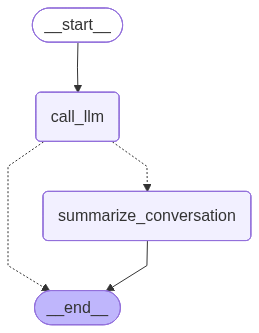

In [9]:
builder = StateGraph(State)
builder.add_node("call_llm", call_llm)
builder.add_node("summarize_conversation", summarize_conversation)
builder.add_edge(START, "call_llm")
builder.add_conditional_edges("call_llm", summarize_condition)
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)
graph

# Testing

In [10]:
config={"configurable": {"thread_id": "1"}}

graph.invoke({'messages': [HumanMessage(content="What sound does a squirrel make?")]}, config)

{'messages': [HumanMessage(content='What sound does a squirrel make?', additional_kwargs={}, response_metadata={}, id='71d110be-35c5-4447-be88-8e14f44811d6'),
  AIMessage(content='Squirrels produce a variety of sounds depending on their species and the situation they are in. Common sounds include:\n\n1. **Chattering:** Squirrels often make rapid, repetitive "chattering" or "kuks," which can convey alarm or territoriality. It sounds like a series of short, sharp clicks or clucks.\n\n2. **Quaas:** These are longer, moaning sounds that can be used as alarm calls or to signal distress.\n\n3. **Squeaks:** Squirrels, especially young ones, might emit high-pitched squeaks when calling for attention or when they feel threatened.\n\n4. **Barks:** Short, sharp barks might be used to warn other squirrels of danger.\n\n5. **Whines or trills:** Sometimes squirrels emit lower calls that sound like a whine or a trill, which can be communication between a mother and her young or within a group.\n\nEac

In [11]:
graph.invoke({'messages': [HumanMessage(content="What sound does a cat make?")]}, config)

{'messages': [HumanMessage(content='What sound does a squirrel make?', additional_kwargs={}, response_metadata={}, id='71d110be-35c5-4447-be88-8e14f44811d6'),
  AIMessage(content='Squirrels produce a variety of sounds depending on their species and the situation they are in. Common sounds include:\n\n1. **Chattering:** Squirrels often make rapid, repetitive "chattering" or "kuks," which can convey alarm or territoriality. It sounds like a series of short, sharp clicks or clucks.\n\n2. **Quaas:** These are longer, moaning sounds that can be used as alarm calls or to signal distress.\n\n3. **Squeaks:** Squirrels, especially young ones, might emit high-pitched squeaks when calling for attention or when they feel threatened.\n\n4. **Barks:** Short, sharp barks might be used to warn other squirrels of danger.\n\n5. **Whines or trills:** Sometimes squirrels emit lower calls that sound like a whine or a trill, which can be communication between a mother and her young or within a group.\n\nEac

In [12]:
graph.invoke({'messages': [HumanMessage(content="and rats?")]}, config)

{'messages': [AIMessage(content="Rats, like many other animals, use vocalizations to communicate with one another. While some sounds are audible to humans, others fall within the ultrasonic range. Here are some common sounds that rats make:\n\n1. **Squeaks:** Rats often emit squeaks that vary in pitch and intensity. High-pitched squeaks can indicate excitement, playfulness, or distress.\n\n2. **Chattering:** This sound is made by chattering or grinding their teeth together, known as bruxing. It's generally a sign of contentment and relaxation, similar to a cat's purr.\n\n3. **Hissing or Hissing-like Sounds:** Some rats may hiss when they feel threatened or are in a defensive mode.\n\n4. **Ultrasonic Vocalizations:** Rats communicate frequently in the ultrasonic range, which is inaudible to humans. These sounds can indicate different types of social interactions, such as mating calls or distress signals.\n\n5. **Whining or Whimpering:** This kind of sound can indicate discomfort, annoya

In [13]:
graph.invoke({'messages': [HumanMessage(content="and what about camels?")]}, config)

{'messages': [AIMessage(content="Rats, like many other animals, use vocalizations to communicate with one another. While some sounds are audible to humans, others fall within the ultrasonic range. Here are some common sounds that rats make:\n\n1. **Squeaks:** Rats often emit squeaks that vary in pitch and intensity. High-pitched squeaks can indicate excitement, playfulness, or distress.\n\n2. **Chattering:** This sound is made by chattering or grinding their teeth together, known as bruxing. It's generally a sign of contentment and relaxation, similar to a cat's purr.\n\n3. **Hissing or Hissing-like Sounds:** Some rats may hiss when they feel threatened or are in a defensive mode.\n\n4. **Ultrasonic Vocalizations:** Rats communicate frequently in the ultrasonic range, which is inaudible to humans. These sounds can indicate different types of social interactions, such as mating calls or distress signals.\n\n5. **Whining or Whimpering:** This kind of sound can indicate discomfort, annoya

In [14]:
graph.invoke({'messages': [HumanMessage(content="and what about ducks?")]}, config)

{'messages': [],
 'summary': 'The user initially asked about the sounds squirrels make, to which the AI responded by describing chattering, quaas, squeaks, barks, and whines or trills, each serving communication purposes. The user then inquired about the sounds cats make, and the AI described various cat sounds such as meow, purr, hiss, growl, chirp, trill, and yowl, noting contextual meanings. The user later asked what sounds rats make, receiving a detailed list including squeaks, chattering, hissing, ultrasonic vocalizations, and whining, noting communication context and body language. Subsequently, the user asked about camel sounds, and the AI provided information on grunts, moans and groans, roars, bleats, and bellows, explaining their communicative functions. Finally, the user asked about duck sounds, and the AI listed quacks, whistles, grunts, coos and squeaks, hisses, and rumbles, indicating their use in communication and interaction.'}

In [15]:
graph.invoke({'messages': [HumanMessage(content="Chickens?")]}, config)

{'messages': [HumanMessage(content='Chickens?', additional_kwargs={}, response_metadata={}, id='2c22378a-81b2-4e13-bdc1-b723a1bb024c'),
  AIMessage(content='Chickens produce a variety of sounds, each with different meanings and purposes:\n\n1. **Clucking**: Hens often cluck softly, particularly when they\'re content or communicating with their chicks. They also cluck more loudly post-laying.\n\n2. **Crowing**: Roosters are known for their crowing, which is typically a signal to establish territory or alert the flock to potential threats. \n\n3. **Purring**: Much like cats, chickens sometimes make a soft purring sound when they are calm and content, often when roosting or dust bathing.\n\n4. **Squawking**: This loud, sharp sound is usually a sign of distress or an alarm call to warn other chickens of danger.\n\n5. **Cackling**: Hens emit a series of cackling sounds after laying an egg, often referred to as the "egg song."\n\n6. **Trilling**: A low, musical sound used in contentment, oft